In [1]:
import matplotlib.pyplot as plt
import numpy as np
from files.utils import rect, tri, ctft2ictft, plotter
%matplotlib inline

## Άσκηση - Επίδειξη μιας απλής προσέγγισης του Μετασχ. Fourier

Ο μετασχ. Fourier είναι μια συνεχής συνάρτηση του $f$, ως εκ τούτου δεν μπορεί να υλοποιηθεί απ' ευθείας σε υπολογιστή - πρέπει πρώτα να τον "διακριτοποιήσουμε"/προσεγγίσουμε με κάποιο τρόπο, και αναγκαστικά να εισάγουμε σφάλμα. Το σφάλμα αυτό προέρχεται από τρεις πηγές.

1. Από το γεγονός ότι ο άξονας του χρόνου δε θα είναι ($-\infty, +\infty$) όπως στη θεωρία αλλά κάποιο πεπερασμένο διάστημα $(-Τ, Τ)$.
2. Από το γεγονός ότι ο άξονας της συχνότητας δε θα είναι ($-\infty, +\infty$) όπως στη θεωρία αλλά κάποιο πεπερασμένο διάστημα $(-Β, Β)$.
3. Από το γεγονός ότι τα παραπάνω πεπερασμένα διαστήματα δεν περιέχουν άπειρες χρονικές/συχνοτικές στιγμές αλλά πεπερασμένες (π.χ. στο διάστημα $(-2,2)$ μπορούμε να πάρουμε πολλά δείγματα, αλλά όχι άπειρα).

---

$\underline{Σημείωση}:$ Στην `Python`, φυσικά, υπάρχουν πολλές βιβλιοθήκες που διαθέτουν συνάρτηση για τον υπολογισμό **κάποιου** μετασχηματισμού Fourier ενός σήματος, με τις πιο δημοφιλείς να είναι οι $\texttt{fft/ifft}$ της βιβλιοθήκης $\texttt{NumPy}$ και οι (ακόμα πιο γρήγορες) $\texttt{fft/ifft}$ της βιβλιοθήκης $\texttt{SciPy}$.  Παρ΄ όλα αυτά, εμείς θα φτιάξουμε τις δικές µας, για να έχουμε απόλυτο έλεγχο. Σε άλλη άσκηση σε αυτόν τον κατάλογο θα δείτε πως να χρησιμοποιείτε αυτές τις έτοιμες συναρτήσεις για να υλοποιήσετε το μετασχ. Fourier που συζητάμε.

---

$\left(\alpha'\right)$ Ας πάμε να υπολογίσουμε το μετασχ. Fourier (και να απεικονίσουμε το φάσμα πλάτους) του πολύ γνωστού μας σήματος 

$$\large x(t) = e^{-at}u(t), \: \: a > 0$$

για κάποια τιμή του $a$. Γνωρίζετε ήδη ότι

$$\large X(f) = \frac{1}{a + j2\pi f}$$

Ας ξεκινήσουμε στο πεδίο του χρόνου, κατασκευάζοντας το σήμα $x(t)$ για $a=2$ και για διάρκεια μόλις $10$ δευτερολέπτων (αντί για άπειρη διάρκεια που έχει κανονικά το σήμα).

(i.) ΠΡΟΣΕΞΕΤΕ: Ο άξονας t θα έχει τις τιμές: [0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1 ] ... [ 9.91  9.92  9.93  9.94  9.95  9.96  9.97  9.98  9.99 10.  ] sec

(ii.) Πόσες χρονικές στιγμές πήραμε? 1000!


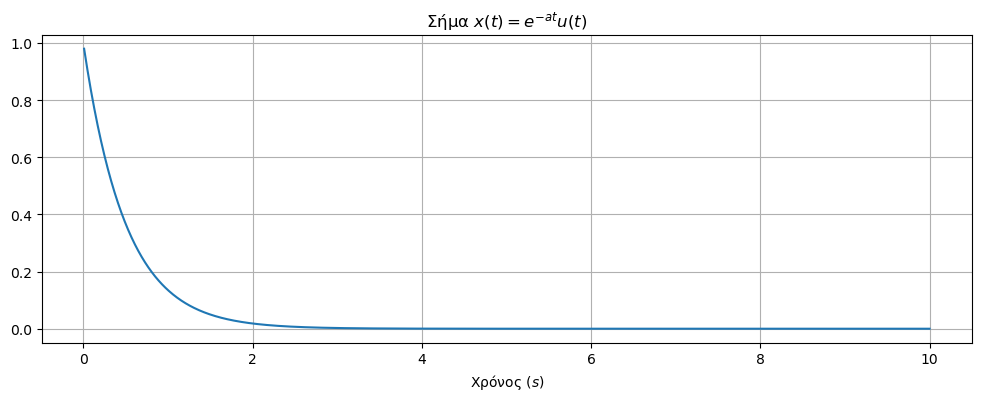

In [2]:
Dt = 0.01                                   # Βήμα στο χρόνο
D = 10                                      # Διάρκεια του σήματος (θεωρητικά είναι άπειρης διάρκειας αλλά... you know :) )
t = np.arange(start=Dt, stop=D+Dt, step=Dt)  # Άξονας του χρόνου, από 0+ ως D=10 με βήμα Dt <--- ΠΑΡΑΤΗΡΗΣΤΕ ΠΩΣ ΔΕΙΓΜΑΤΟΛΗΠΤΗΣΑΜΕ ΤΟ ΣΥΝΕΧΗ ΑΞΟΝΑ t!

print(f"(i.) ΠΡΟΣΕΞΕΤΕ: Ο άξονας t θα έχει τις τιμές: {t[0:10]} ... {t[-10:]} sec\n")
print(f"(ii.) Πόσες χρονικές στιγμές πήραμε? {len(t)}!")

a = 2                                    # Παράμετρος α, έστω ίση με 2 στο παράδειγμά μας
x = np.exp(-a*t)                         # Σήμα (δε χρειάζεται η βηματική u(t) γιατί ο άξονας t, όπως τον φτιάξαμε, ξεκινά από το μηδέν)

plt.figure(figsize=(12,4))               # Σχήμα (μέγεθος)
plt.plot(t, x)                           # Γράφημα
plt.xlabel("Χρόνος $(s)$")               # Ομορφαίνουμε
plt.title("Σήμα $x(t) = e^{-at}u(t)$")   # Ομορφαίνουμε
plt.grid()                               # Ομορφαίνουμε
plt.show()

Εδώ παραλείψαµε να χρησιμοποιήσουμε ρητά τη βηµατική συνάρτηση $u(t)$, αφού ο άξονας του χρόνου $t$ που δηµιουργήσαµε πριν ορίζεται για $t>0$, οπότε ουσιαστικά την έχουμε "ενσωματώσει" κατά τη δημιουργία του άξονα $t$.

Έστω ότι θέλουμε να βρούμε το συχνοτικό περιεχόμενο του σήματος στο διάστηµα $f \in [−10, 10]$ Hz, µε ίδια "ανάλυση" (βήμα) όπως και στο πεδίο του χρόνου, δηλ. $0.01$ Hz. Κατασκευάζουµε τον άξονα των συχνοτήτων ως :

In [3]:
Df = 0.01                                      # Βήμα στη συχνότητα
f = np.arange(start=-10, stop=10+Df, step=Df)  # Άξονας της συχνότητας, [-10, 10] Hz με βήμα Df  <--- ΠΑΡΑΤΗΡΗΣΤΕ ΠΩΣ ΔΕΙΓΜΑΤΟΛΗΠΤΗΣΑΜΕ ΤΟ ΣΥΝΕΧΗ ΑΞΟΝΑ f!

print(f"(i.) ΠΡΟΣΕΞΤΕ: Ο άξονας f θα έχει τις τιμές: {f[0:5]} ... {f[-5:]} Hz\n")
print(f"(ii.) Πόσες συχνοτικές στιγμές πήραμε? {len(f)}!")

(i.) ΠΡΟΣΕΞΤΕ: Ο άξονας f θα έχει τις τιμές: [-10.    -9.99  -9.98  -9.97  -9.96] ... [ 9.96  9.97  9.98  9.99 10.  ] Hz

(ii.) Πόσες συχνοτικές στιγμές πήραμε? 2001!


Θεωρούμε λοιπόν ότι µας ενδιαφέρουν μόνο οι παραπάνω συχνότητες $[−10, 10]$ Hz, µε ανάλυση $Df$, και ότι σε αυτές τις συχνότητες, $2001$ το πλήθος, θα υπολογίσουμε τον μετασχηματισμό Fourier. ΄Αρα, ουσιαστικά, θα "βλέπουμε" τον μετασχηματισμό Fourier μόνο στο διάστηµα $[−10, 10]$ Hz. 

Γνωρίζοντας τα δείγματα του χρόνου και της συχνότητας μπορούμε να κατασκευάσουµε το λεγόμενο $\textit{πίνακα ανάλυσης}$ του μετασχηματισμού Fourier:

$$\large M(f_l, t_n) = e^{−j2πf_l t_n} = \begin{bmatrix} e^{-j2\pi t_{1} f_{1}} & e^{-j2\pi t_2 f_1} & \cdots & e^{-j2\pi t_{1000} f_1} \\
e^{-j2\pi t_{1} f_{2}} & e^{-j2\pi t_2 f_2} & \cdots & e^{-j2\pi t_{1000} f_{2}} \\
\cdots & \cdots & \cdots & \cdots\\
\cdots & \cdots & \cdots & \cdots\\
e^{-j2\pi t_{1} f_{1999}} & e^{-j2\pi t_{2} f_{1999}} & \cdots & e^{-j2\pi t_{1000} f_{1999}} \\
e^{-j2\pi t_{1} f_{2000}} & e^{-j2\pi t_{2} f_{2000}} & \cdots & e^{-j2\pi t_{1000} f_{2000}} \\
e^{-j2\pi t_{1} f_{2001}} & e^{-j2\pi t_{2} f_{2001}} & \cdots & e^{-j2\pi t_{1000} f_{2001}} 
 \end{bmatrix}$$

με τους δείκτες $n, l$ να υποδεικνύουν ότι οι μεταβλητές αυτές είναι διακριτές: έχουμε λάβει μόνο κάποια δείγματα από τις συνεχείς μεταβλητές $f, t$, όπως ακριβώς κάναμε μόλις πριν, χρησιμοποιώντας τα βήματα $Dt$, $Df$, για να δειγματοληπτήσουμε τους αντίστοιχους άξονες. Μάλιστα πήραμε $2001$ δείματα στο χώρο της συχνότητας και $1000$ δείγματα στο χώρο του χρόνου! 

Βλέπετε ότι η πρώτη γραμμή του πίνακα περιλαμβάνει τα μιγαδικά εκθετικά με συχνότητα $f_1$, για κάθε χρονική στιγμή $t$ ($t_1, t_2, \cdots, t_{1000}$) που πήραμε κατά τη δειγματοληψία της συνεχούς μεταβλητής $t$. Η δεύτερη γραμμή περιλαμβάνει τα μιγαδικά εκθετικά με συχνότητα $f_2$, ξανά για κάθε χρονική στιγμή $t$ που δειγματοληπτήσαμε. Άρα η $l-$οστή γραμμή θα περιλαμβάνει τα μιγαδικά εκθετικά σήματα με συχνότητα $f_l$ για κάθε χρονική στιγμή $t$.

Όμοια, βλέπετε ότι η πρώτη στήλη του πίνακα περιλαμβάνει τα μιγαδικά εκθετικά τη χρονική στιγμή $t_1$, για κάθε συχνότητα $f$ ($f_1, f_2, \cdots, f_{2001}$) που πήραμε κατά τη δειγματοληψία της συνεχούς μεταβλητής $f$. Η δεύτερη γραμμή περιλαμβάνει τα μιγαδικά εκθετικά τη χρονική στιγμή $t_2$, για κάθε συχνότητα $f$ που δειγματοληπτήσαμε. Άρα η $n-$οστή στήλη θα περιλαμβάνει τα μιγαδικά εκθετικά σήματα τη χρονική στιγμή $t_n$ για κάθε συχνότητα $f$ που δειγματοληπτήσαμε.

Ας τον κατασκευάσουμε!

In [4]:
tt = np.expand_dims(t, axis=0)        # Προσθέτουμε μια έξτρα διάσταση στο χρόνο: από [1001] -> [1,1001]
ff = np.expand_dims(f, axis=0)        # Προσθέτουμε μια έξτρα διάσταση στη συχνότητα: από [2001] -> [1,2001]

M = np.exp(-1j * 2 * np.pi * ff.T @ tt) # M(f_l, t_n): Σύμφωνα με τη γραμμική άλγεβρα: [2001 x 1] * [1 x 1001] = [2001 x 1001]

print(f"Πριν: Διαστάσεις t = {t.shape}, f = {f.shape}, \
      Μετά: Διαστάσεις t = {tt.shape}, f = {ff.shape}")   # Ελέγξτε τις διαστάσεις πριν και μετά την επέκταση

Πριν: Διαστάσεις t = (1000,), f = (2001,),       Μετά: Διαστάσεις t = (1, 1000), f = (1, 2001)


**Σημείωση 1**: Η `Python` έχει κάποιες ιδιαιτερότητες στις πράξεις με διανύσματα: χρειάζεται να τους προσθέσουμε μια έξτρα διάσταστη, ώστε να τηρούνται οι κανόνες της Γραμμικής Άλγεβρας στις πράξεις μεταξύ διανυσμάτων. Η διάσταση αυτή δεν αλλάζει σε τίποτα τα δεδομένα μας, απλά χρησιμοποιείται για το λόγο που αναφέραμε.

**Σημείωση 2**: Το $\texttt{.Τ}$ attribute (που βλέπετε στην 3η γραμμή παραπάνω) ενός $\texttt{NumPy}$ διανύσματος/πίνακα μας επιστρέφει τον $\textit{ανάστροφό}$ του, και πολλές φορές χρησιμοποιείται για να συμφωνούν οι διαστάσεις των πινάκων που εμπλέκονται ως γινόμενα, ενώ ο τελεστής "@" δηλώνει πολλαπλασιασμό πινάκων/διανυσμάτων, με βάση τους κανόνες της Γραμμικής Άλγεβρας.



Έχουμε λοιπόν τον πίνακα $\mathbf{M}(f_l, t_n)$, μεγέθους $2001$ x $1000$: έχουμε $2001$ δείγματα από τον άξονα συχνότητας και $1000$ δείγματα από τον άξονα του χρόνου, "παρμένα" ομοιόμορφα στα διαστήματα $[-10, 10]$ Hz και $(0,10]$ s, αντίστοιχα, και έχουμε κατασκευάσει τα μιγαδικά εκθετικά μας σήματα $e^{-j2\pi f_l t_n}$, συνδυάζοντας κάθε τιμή $t_n$ με κάθε τιμή $f_l$.

Για να υπολογίσουµε τον µετασχηματισμό Fourier, θα χρησιμοποιήσουμε το **άθροισµα Riemann** (θυμηθείτε το 2ο εργαστήριο), δηλ. θα δηµιουργήσουµε την προσέγγιση του µετασχηματισμού Fourier ως:

$$\large X(f) = \int_{-\infty}^{+\infty}x(t)e^{-j2\pi ft}dt \approx \sum_{n=-\infty}^{+\infty} \left(x\left( t_n \right) e^{-j2\pi f_l t_n}\Delta t\right) = \Delta t \cdot \mathbf{M}\cdot \mathbf{x}$$

Το αποτέλεσμα αυτής της πράξης θα είναι ένα διάνυσμα που θα περιέχει τις (μιγαδικές, εν γένει) τιμές του Μετασχ. Fourier στις ($2001$ το πλήθος) συχνότητες $f_l$ που έχουμε επιλέξει!


---
#### <span style="color:orange">**Εξήγηση (μπορείτε να την παραλείψετε, ειδικά αν η παραπάνω σχέση πολλαπλασιασμού πινάκων σας φαίνεται προφανής)** </span>.

Γιατί γράψαμε την τελευταία σχέση που περιλαμβάνει πολλαπλασιασμούς πινάκων? Δεν μπορούμε να υλοποιήσουμε το άθροισμα με χρήση `for` loops? Η απάντηση είναι "ναι". Θα γράφαμε:

```
t = np.arange(...)
f = np.arange(...)

X = np.zeros(f.shape)

for t_i in range(0, len(t)):
    X = X + x[t_i] * np.exp(-1j * 2 * np.pi * f * t[t_i])

X = dt*X
``` 

και στο διάνυσμα `Χ` θα είχαμε το μετασχηματισμό Fourier, χωρίς κανένα απολύτως πρόβλημα.

Όμως η γραφή με πίνακες είναι πολύ πιο κομψή και σύντομη - απλά χρησιμοποιεί Γραμμική Άλγεβρα που δεν υποθέτουμε ότι όλοι/ες γνωρίζετε σε υψηλό επίπεδο αλλά θεωρούμε ότι έχετε μια ΠΟΛΥ επιφανειακή γνώση. Ας την εξηγήσουμε.

Ας θυμηθούμε ένα πολύ απλό παράδειγμα από τη Γραμμική Άλγεβρα και τον πολλαπλασιασμό πίνακα $3\times 2$ με διάνυσμα $2\times 1$:

$$ \mathbf{A}\cdot \mathbf{b} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \\ a_{31} & a_{32} \end{bmatrix} \cdot \begin{bmatrix} b_1 \\ b_2 \end{bmatrix} = \begin{bmatrix} a_{11}b_1 + a_{12}b_2 \\ a_{21}b_1 + a_{22}b_2 \\ a_{31}b_1 + a_{32}b_2 \end{bmatrix} = \mathbf{c} = \begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix}$$

Ας υποθέσουμε ότι στον υπολογισμό του μετασχ. Fourier έχουμε *μόνο* δυο χρονικές στιγμές, $t_1, t_2$ και *μόνο* τρεις συχνοτικές τιμές, $f_1, f_2, f_3$ (αντί για $1000$ και $2001$ αντίστοιχα, που έχουμε στο παράδειγμά μας). Θα συμφωνήσετε ότι για τη συχνότητα $f_1$, ο μετασχ. Fourier μέσω της προσέγγισης Riemann θα γράφεται ως 

$$X(f_1) = x(t_1)e^{-j2\pi f_1 t_1}\Delta t + x(t_2)e^{-j2\pi f_1 t_2}\Delta t$$

Αυτό δε μοιάζει με την πρώτη γραμμή του διανύσματος $\mathrm{c}$ παραπάνω?

Αν επαναλάβουμε για τη συχνότητα $f_2$, ο μετασχ. Fourier μέσω της προσέγγισης Riemann θα γράφεται ως 

$$X(f_2) = x(t_1)e^{-j2\pi f_2 t_1}\Delta t + x(t_2)e^{-j2\pi f_2 t_2}\Delta t$$

Αυτό δε μοιάζει με την δεύτερη γραμμή του διανύσματος $\mathrm{c}$ παραπάνω?

Ας κάνουμε το ίδιο και για την τρίτη συχνότητα:

$$X(f_3) = x(t_1)e^{-j2\pi f_3 t_1}\Delta t + x(t_2)e^{-j2\pi f_3 t_2}\Delta t$$

Καταλαβαίνετε ότι το παραπάνω μοιάζει με την τρίτη γραμμή του διανύσματος $\mathrm{c}$ παραπάνω! 

Μπορούμε λοιπόν να γράψουμε

$$X(f) = \begin{bmatrix} X(f_1) \\ X(f_2) \\ X(f_3) \end{bmatrix} = \begin{bmatrix} x(t_1)e^{-j2\pi f_1 t_1}\Delta t + x(t_2)e^{-j2\pi f_1 t_2}\Delta t \\
x(t_1)e^{-j2\pi f_2 t_1}\Delta t + x(t_2)e^{-j2\pi f_2 t_2}\Delta t \\
x(t_1)e^{-j2\pi f_3 t_1}\Delta t + x(t_2)e^{-j2\pi f_3 t_2}\Delta t \end{bmatrix}$$

Παρατηρώντας το απλό παράδειγμα από τη Γραμμική Άλγεβρα παραπάνω, μπορούμε να δουλέψουμε αντίστροφα και να γράψουμε:

$$X(f) = \Delta t \begin{bmatrix} e^{-j2\pi f_1 t_1} \: \: \: \: e^{-j2\pi f_1 t_2} \\ e^{-j2\pi f_2 t_1} \: \: \: \: e^{-j2\pi f_2 t_2} \\ e^{-j2\pi f_3 t_1} \: \: \: \: e^{-j2\pi f_3 t_2}  \end{bmatrix} \cdot \begin{bmatrix} x(t_1) \\ x(t_2) \end{bmatrix} = \Delta t \cdot \mathbf{M} \cdot \mathbf{x}$$

Να λοιπόν πως μπορούμε να βρούμε το μετασχ. Fourier κάνοντας πολλαπλασιασμό πινάκων!

Επιστρέφοντας στο αρχικό παράδειγμα της άσκησης, ο πίνακας $\mathbf{M}(f_l, t_n)$, διάστασης $2001 \times 1000$, θα είναι (με βάση την παραπάνω γραφή) της μορφής

$$\mathbf{M} = \begin{bmatrix} e^{-j2\pi t_{1} f_{1}} & e^{-j2\pi t_2 f_1} & \cdots & e^{-j2\pi t_{1000} f_1} \\
e^{-j2\pi t_{1} f_{2}} & e^{-j2\pi t_2 f_2} & \cdots & e^{-j2\pi t_{1000} f_{2}} \\
\cdots & \cdots & \cdots & \cdots\\
\cdots & \cdots & \cdots & \cdots\\
e^{-j2\pi t_{1} f_{1999}} & e^{-j2\pi t_{2} f_{1999}} & \cdots & e^{-j2\pi t_{1000} f_{1999}} \\
e^{-j2\pi t_{1} f_{2000}} & e^{-j2\pi t_{2} f_{2000}} & \cdots & e^{-j2\pi t_{1000} f_{2000}} \\
e^{-j2\pi t_{1} f_{2001}} & e^{-j2\pi t_{2} f_{2001}} & \cdots & e^{-j2\pi t_{1000} f_{2001}} 
 \end{bmatrix}$$

με τους δείκτες στις μεταβλητές $t$ και $f$ να δηλώνουν το στοιχείο τους που χρησιμοποιείται (π.χ. η τιμή $f_{1500}$ υποδηλώνει το στοιχείο του διανύσματος $f$ που βρίσκεται στη θέση $1500$ - δε σχετίζεται με τη συχνότητα $1500$ Hz, η οποία άλλωστε δεν υπάρχει στο παράδειγμα: κοιτάζουμε τις συχνότητες μόνο στο διάστημα $[-10, 10]$ Hz!). Ο πίνακας αυτός περιλαμβάνει όλους τους δυνατούς συνδυασμούς τιμών της συνάρτησης $e^{-j2\pi f_l t_n}$, για τις τιμές $$t_n \in \{dt, 2dt, \cdots, 10\}$$ και $$f_l \in \{-10, -10+df, -10+2df, \cdots, 10-df, 10\}$$

Το διάνυσμα $\mathrm{x}$, που είναι το σήμα $x(t_n)$, διάστασης $1 \times 1000$, είναι της μορφής

$$x = \begin{bmatrix} x_1 & x_2 & x_3 & \cdots & x_{1000} \end{bmatrix}^T$$

Εμείς θέλουμε να κατασκευάσουμε το άθροισμα Riemann που δείξαμε ότι μπορεί να γραφεί ως 

$$\Delta t \cdot \mathbf{M}\cdot \mathbf{x}$$

Το κακό είναι ότι οι διαστάσεις του διανύσματος $\mathbf{x}$, όπως το κατασκευάσαμε πριν, είναι $1\times 1000$ και του πίνακα $\textbf{M}$ είναι $2001 \times 1000$. Σύμφωνα με τη Γραμμική Άλγεβρα, το γινόμενο $\mathbf{M}\cdot \mathbf{x}$ των δυο δεν μπορεί να πραγματοποιηθεί. 

Αν όμως αναστρέψουμε το διάνυσμα $\mathbf{x}$, κατασκευάσουμε δηλ. το διάνυσμα $\mathbf{x}^T$, τότε θα έχει διαστάσεις $1000 \times 1$, και πολλαπλασιαζόμενο με τον πίνακα $\mathbf{M}$ διαστάσεων $2001 \times 1000$, το γινόμενο $\mathbf{M}\cdot \mathbf{x}^T$ ικανοποιεί τους κανόνες πολλαπλασιασμού της Γραμμικής Άλγεβρας και δίνει αποτέλεσμα διαστάσεων $2001 \times 1$!

Φυσικά μπορούμε να αναστρέψουμε τον πίνακα $\mathbf{M}$, και να υλοποιήσουμε το γινόμενο $\mathbf{x} \cdot \mathbf{M}^T$, που θα μας δώσει το ίδιο αποτέλεσμα αλλά σε ανεστραμμένη μορφή. 

Παρακάτω υλοποιούμε την προηγούμενη προσέγγιση.

#### <span style="color:orange">**Τέλος εξήγησης**</span>
---


Ένας τρόπος να υλοποιηθεί αυτό το άθροισμα Riemann στην `Python` είναι:

In [5]:
xx = np.expand_dims(x, axis=0)    # Προσθέτουμε την έξτρα διάσταση στο σήμα x για να ισχύει η γραμμική άλγεβρα

X = Dt * M @ xx.T                 # Άθροισμα Riemann: [2001 x 1000] * [1000 x 1] = [2001 x 1]: 2001 τιμές του μετασχηματισμού στη συχνότητα, όπως αναμενόταν

X = np.squeeze(X)                 # "Kόβουμε" την έξτρα διάσταση ώστε να είναι πιο διαχειρίσιμο στα γραφήματα

Ας συγκρίνουμε το φάσμα πλάτους του παραπάνω με το θεωρητικό φάσμα πλάτους που ξέρουμε:

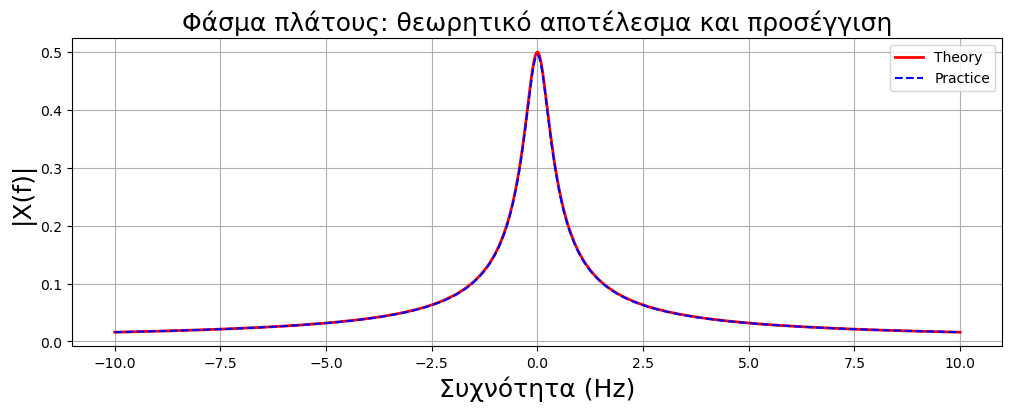

In [6]:
plt.figure(figsize=(12,4))
Xtheoretic = 1 / (a + 1j*2*np.pi*f)  
plt.plot(f, np.abs(Xtheoretic), 'r', linewidth=2, label="Theory")
plt.plot(f, np.abs(X), 'b--', linewidth=1.5, label="Practice")
plt.legend()
plt.title('Φάσμα πλάτους: θεωρητικό αποτέλεσμα και προσέγγιση', fontsize=18)
plt.xlabel("Συχνότητα (Hz)", fontsize=18)
plt.ylabel("|X(f)|", fontsize=18)
plt.grid()
plt.show()

**Εκπληκτικό**!! Η προσέγγισή μας είναι εξαιρετικά καλή, καθώς δεν μπορούμε εύκολα να διακρίνουμε τα δυο φάσματα πλάτους. Ας δούμε απλά πόσο είναι το σφάλμα σε κάθε συχνότητα αλλά και το μέγιστο σφάλμα μεταξύ τους:

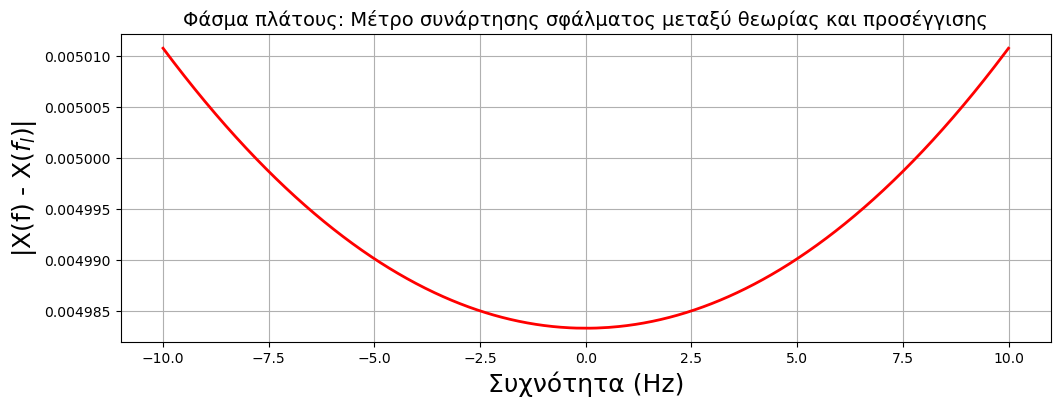

Το μέγιστο σφάλμα μεταξύ της θεωρίας και της προσέγγισης είναι 0.005010796320542224


In [7]:
plt.figure(figsize=(12,4))
error = np.abs(Xtheoretic - X)
plt.plot(f, error, 'r', linewidth=2)
plt.title('Φάσμα πλάτους: Μέτρο συνάρτησης σφάλματος μεταξύ θεωρίας και προσέγγισης', fontsize=14)
plt.xlabel("Συχνότητα (Hz)", fontsize=18)
plt.ylabel("|X(f) - X($f_l$)|", fontsize=18)
plt.grid()
plt.show()

Max_error = np.max(np.abs(X-Xtheoretic))
print(f"Το μέγιστο σφάλμα μεταξύ της θεωρίας και της προσέγγισης είναι {Max_error}")

---


$\left(\beta'\right)$ Ας προσπαθήσουµε τώρα να συνθέσουµε το σήµα στο χρόνο µέσω του αντίστροφου µετασχηματισμού Fourier, δηλ. ας προσπαθήσουµε να βρούµε το σήµα στο χρόνο, $x(t)$, χρησιμοποιώντας το Μετασχ. Fourier! Ο µετασχ. Fourier που έχουµε βρει ορίζεται µόνο στο διάστηµα $f \in [−10, 10]$ Hz, ενώ έχουμε κάνει και δειγματοληψία ανά $0.01$ Hz στο διάστημα αυτό, αρα σίγουρα θα έχουµε κάποιο σφάλµα και στον υπολογισµό του $x(t)$.

Γνωριζοντας τα δείγµατα του χρόνου και της συχνότητας µπορούµε να κατασκευάσουµε το λεγόµενο $\textit{πίνακα σύνθεσης}$ του αντίστροφου µετασχ. Fourier:

$$\large M_{inv}(f_l, t_n) = e^{j2πf_l t_n}$$

με τους δείκτες $l, n$ να υποδεικνύουν ξανά ότι οι μεταβλητές αυτές είναι διακριτές: έχουμε λάβει μόνο κάποια δείγματα από τις συνεχείς μεταβλητές $f, t$.

In [8]:
# Έχουμε ήδη τακτοποιήσει τις επεκτάσεις των αξόνων t -> tt και f -> ff, οπότε δε χρειάζεται να το επαναλάβουμε

Minv = np.exp(1j * 2 * np.pi * tt.T @ ff) # M_inv(f_l, t_n): Σύμφωνα με τη γραμμική άλγεβρα: 
                                          # [1000 x 1] * [1 x 2001] = [1000 x 2001]

Τώρα έχουμε τον πίνακα $M_{inv}(f_l, t_n)$, μεγέθους $1000$ x $2001$: έχουμε $1000$ δείγματα από τον άξονα του χρόνου και $2001$ δείγματα από τον άξονα συχνότητας (όπως και πριν), και έχουμε κατασκευάσει τα μιγαδικά εκθετικά μας σήματα $e^{j2\pi f_l t_n}$.

Για να υπολογίσουμε τον αντίστροφο μετασχηματισμό Fourier, θα δουλέψουμε όπως για το άθροισμα Riemann προηγουμένως, µε κάποιες μικρές διαφοροποιήσεις, δηλ. θα δημιουργήσουμε την προσέγγιση του αντίστροφου μετασχηματισμού Fourier ως:

$$\large x(t) = \int_{-\infty}^{+\infty} X(f)e^{j2\pi ft}df \approx \sum_{l=-\infty}^{+\infty} \left(X\left(f_l \right) e^{j2\pi t_n f_l} \Delta f\right) = \Delta f \cdot \mathbf{X} \cdot \mathbf{M_{inv}}^T$$


Η σύνθεση του σήματος στο χρόνο γίνεται ως:

In [9]:
XX = np.expand_dims(X, axis=0)                            # Επαναφέρουμε την έξτρα διάσταση που "κόψαμε" πριν 
                                                          # για λόγους απεικόνισης

x_est = Df * XX @ Minv.T                                  # Αντίστρ. M. Fourier: [1 x 2001] * [2001 x 1000] = [1 x 1000], όπως αναμενόταν

x_est = x_est.real                                        # Λόγω αριθμητικών σφαλμάτων, θα υπάρχει ένα απειροελάχιστο φανταστικό 
                                                          # μέρος στο αποτέλεσμα, το οποίο και απορρίπτουμε κρατώντας το
                                                          # πραγματικό μέρος μόνο - αφού γνωρίζουμε ότι το σήμα μας στο χρόνο είναι πραγματικό

x_est = np.squeeze(x_est)                                 # "Κόβουμε" την έξτρα διάσταση όπως πριν για καλύτερη διαχείριση
                                                          # στα γραφήματα

Ας συγκρίνουμε το αποτέλεσμά µας µε το θεωρητικό:

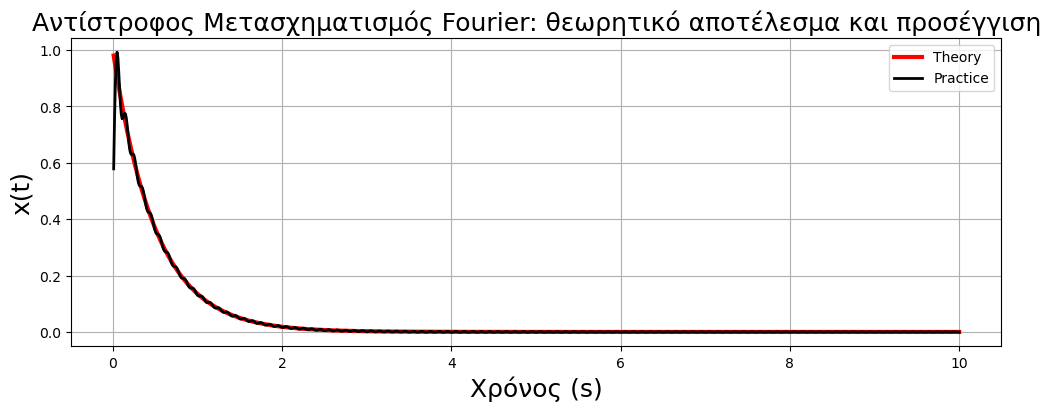

In [10]:
plt.figure(figsize=(12,4))
plt.plot(t, x, 'r', linewidth=3, label="Theory")
plt.plot(t, x_est, 'k', linewidth=2, label="Practice")
plt.title('Αντίστροφος Μετασχηματισμός Fourier: θεωρητικό αποτέλεσμα και προσέγγιση', fontsize=18)
plt.xlabel("Χρόνος (s)", fontsize=18)
plt.ylabel("x(t)", fontsize=18)
plt.legend()
plt.grid()
plt.show()

Εδώ η διαφορά είναι πιο εμφανής! Ας υπολογίσουμε κι εδώ το μέγιστο σφάλμα μεταξύ των δυο συναρτήσεων:

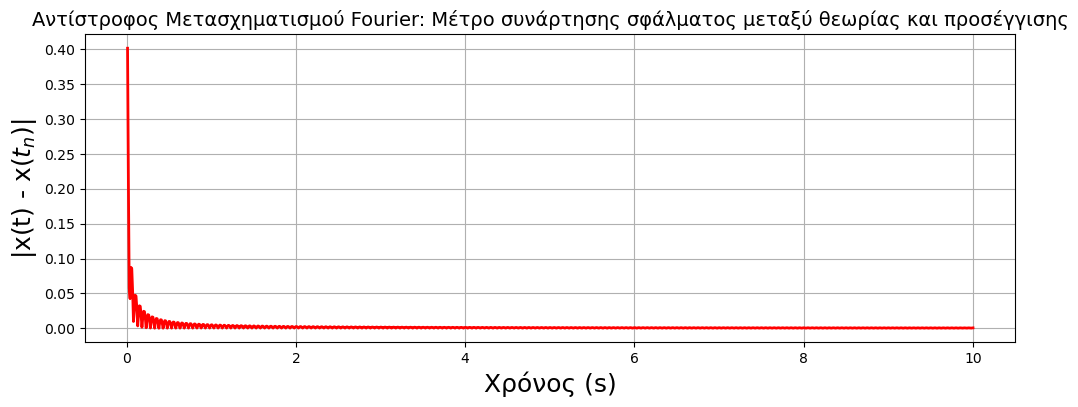

Το μέγιστο σφάλμα μεταξύ της θεωρίας και της προσέγγισης είναι 0.40162456959507264


In [11]:
plt.figure(figsize=(12,4))
error = np.abs(x-x_est)
plt.plot(t, error, 'r', linewidth=2)
plt.title('Αντίστροφος Μετασχηματισμού Fourier: Μέτρο συνάρτησης σφάλματος μεταξύ θεωρίας και προσέγγισης', fontsize=14)
plt.xlabel("Χρόνος (s)", fontsize=18)
plt.ylabel("|x(t) - x($t_n$)|", fontsize=18)
plt.grid()
plt.show()

Max_error = np.max(np.abs(x-x_est))
print(f"Το μέγιστο σφάλμα μεταξύ της θεωρίας και της προσέγγισης είναι {Max_error}")

---
---

Γράψτε κατάλληλο κώδικα για να βρείτε και τυπώσετε τα παρακάτω σήματα:

i. $x_1(t) = -e^{3t}u(-t)$

ii. $x_2(t) = 4\mathrm{rect}(t+1)$

iii. $x_3(t) = 2\mathrm{tri}(t-2)$

iv. $x_4(t) = e^{-|t|}$

**υλοποιώντας τα πρώτα στο πεδίο του χρόνου, βρίσκοντας το μετασχ. Fourier τους, και χρησιμοποιώντας τον για να ξανασυνθέσετε το σήμα στο χρόνο (ακριβώς όπως στο παραπάνω παράδειγμα)**. Σας δίνεται βοηθητικός κώδικας παρακάτω.

---

#### <span style="color:orange"> Σημείωση: Βοηθητικές συναρτήσεις:</span> 

Στην βιβλιοθήκη $\texttt{SciPy}$ παρέχονται υλοποιήσεις για τον τετραγωνικό και τριγωνικό παλμό (στο $\texttt{signal}$ υποπακέτο), αλλά θα σας φανούν λίγο περίεργες ως προς την χρήση τους. 

Προς ευκολία σας, σας δίνονται εναλλακτικές, απλούστερες υλοποιήσεις του τετραγωνικού και τριγωνικού παλμού που μοιάζουν πολύ με αυτές που έχουμε δει στο μάθημα. Έχουν ήδη γίνει ``import`` στο πρώτο κελί από το αρχείο ``utils.py`` που σας δίνουμε. Απλά δείτε το πως τις καλείτε.

In [12]:
help(rect)

Help on function rect in module files.utils:

rect(time_axis, dt, A=1, T=1, t_0=0)
    Παράμετροι:
    ----------
    time_axis: ndarray
        άξονας του χρόνου (χωρίς έξτρα διάσταση)
    dt: ndarray
        βήμα στο χρόνο 
    A: float
        πλάτος του τετραγωνικού παλμού 
    T: float
        διάρκεια ολόκληρου παλμού 
    t_0: float
        μετατόπιση: (καθυστέρηση για t_0>0, προήγηση για t_0<0)
    Επιστρέφει:
    -------
    ndarray
        rect(t/T) = {A, t στο (-T/2, T/2)
                    {0, αλλού.



In [13]:
help(tri)

Help on function tri in module files.utils:

tri(time_axis, dt, A=1, T=1, t_0=0)
    Παράμετροι:
    ----------
    time_axis: ndarray
        άξονας του χρόνου (χωρίς έξτρα διάσταση)
    dt: ndarray
        βήμα στο χρόνο 
    A: float
        πλάτος του τριγωνικού παλμού 
    T: float
        διάρκεια ΜΙΣΟΥ παλμού 
    t_0: float
        μετατόπιση: (καθυστέρηση για t_0>0, προήγηση για t_0<0)
    Επιστρέφει:
    -------
    ndarray
        Atri(t/T) = {A(1-|t|/T), t στο (-T, T)
                    {0, αλλού.



Επίσης, σας δίνονται ως συναρτήσεις οι παρακάτω δυο:
- $\texttt{ctft2ictft}$: υπολογίζει το σήμα στο χρόνο $x(t)$ μέσω του αντίστροφου μετασχ. Fourier, αξιοποιώντας το μετασχ. Fourier $X(f)$, εκτελώντας τα βήματα που είδατε πριν
- $\texttt{plotter}$: τυπώνει τη σύγκριση μεταξύ δυο σημάτων **στο χρόνο**: του αυθεντικού και της προσέγγισης μέσω αντιστρ. μετασχ. Fourier

Απλά δείτε πως συντάσσονται, καθώς κι αυτές έχουν γίνει ήδη ``import``.

In [14]:
help(ctft2ictft)

Help on function ctft2ictft in module files.utils:

ctft2ictft(freq, df, time, dt, xx)
    Continuous-Time FT to Inverse Continuous-Time FT
    
    Παράμετροι:
    ----------
    freq: ndarray
        άξονας της συχνότητας (χωρίς την έξτρα διάσταση)
    df: ndarray
        βήμα στη συχνότητα
    time: ndarray
        άξονας του χρόνου (χωρίς την έξτρα διάσταση)
    dt: ndarray
        βήμα στο χρόνο
    xx: ndarray
        σήμα στο χρόνο
    Επιστρέφει:
    -------
    x_inv: ndarray
        το σήμα στο χρόνο υπολογισμένο μέσω του μετασχηματισμού Fourier, ως αποτέλεσμα της ακολουθίας πράξεων: 
        
                                              xx(t) -> X(f) -> x_inv(t)



In [15]:
help(plotter)

Help on function plotter in module files.utils:

plotter(time, signal, signal_est, title)
    Παράμετροι:
    ----------
    time: ndarray
        άξονας του χρόνου (χωρίς την έξτρα διάσταση)
    signal: ndarray
        σήμα στο χρόνο (original) (χωρίς την έξτρα διάσταση)
    signal_est: ndarray
        σήμα στο χρόνο (προσέγγιση μέσω μετασχ. Fourier) (χωρίς την έξτρα διάσταση)
    title: string
        τίτλος γραφήματος
    Επιστρέφει:
    -------
    Γράφημα



---

Συμπληρώστε τον παρακάτω κώδικα:

In [16]:
# Χρησιμοποιήστε τις ακόλουθες μεταβλητές/διανύσματα για όλες τις απαντήσεις σας παρακάτω:
df = 0.01
f = np.arange(start=-10, stop=10+df, step=df)

dt = 0.01
# Ο άξονας του χρόνου t σας δίνεται για το κάθε παράδειγμα

i. $x_1(t) = -e^{3t}u(-t)$

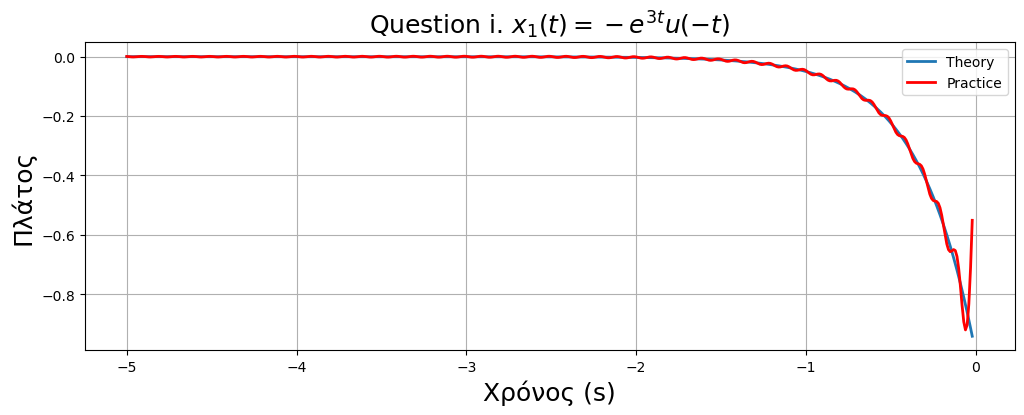

In [17]:
#  i)
t = np.arange(start=-5, stop=-dt, step=dt)
x1 = -np.exp(3*t) # INSERT CODE HERE - υλοποιήστε το σήμα κανονικά στο πεδίο του χρόνου
x1_est = ctft2ictft(f, df, t, dt, x1) # INSERT CODE HERE - χρησιμοποιήστε την ctft2ictft
plotter(time=t, signal=x1, signal_est=x1_est.real, title="Question i. $x_1(t)=-e^{3t}u(-t)$")

ii. $x_2(t) = 4\mathrm{rect}(t+1)$

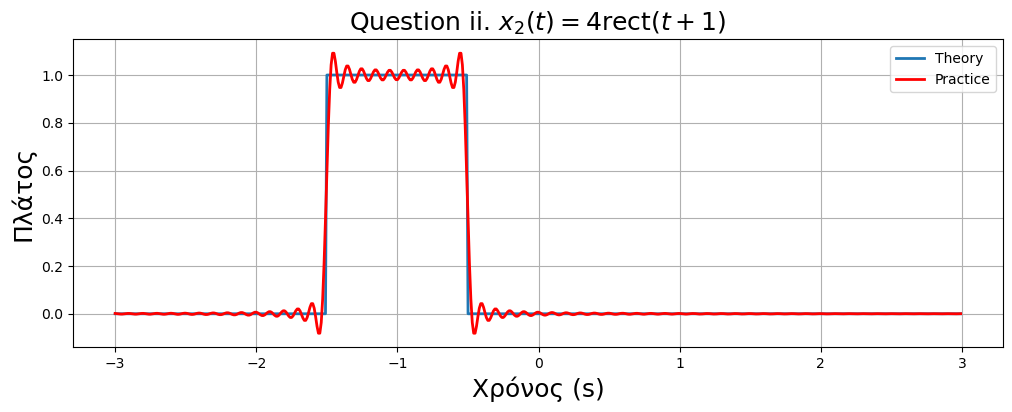

In [18]:
# ii)
t = np.arange(start=-3, stop=3, step=dt)
x2 = rect(t+1, dt, t_0=-1) # INSERT CODE HERE - υλοποιήστε το σήμα κανονικά στο πεδίο του χρόνου
x2_est = ctft2ictft(f, df, t, dt, x2)# INSERT CODE HERE - χρησιμοποιήστε την ctft2ictft
plotter(time=t, signal=x2, signal_est=x2_est.real, title="Question ii. $x_2(t)=4\mathrm{rect}(t+1)$")

iii. $x_3(t) = 2\mathrm{tri}(t-2)$

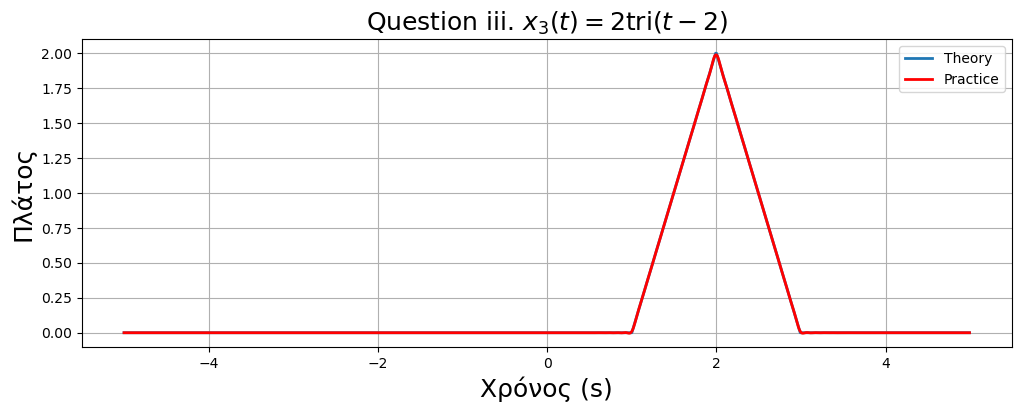

In [19]:
# iii)
t = np.arange(start=-5, stop=5, step=dt)
x3 = tri(t, dt, A=2, T=1, t_0=2) # INSERT CODE HERE - υλοποιήστε το σήμα κανονικά στο πεδίο του χρόνου
x3_est = ctft2ictft(f, df, t, dt, x3) # INSERT CODE HERE - χρησιμοποιήστε την ctft2ictft
plotter(time=t, signal=x3, signal_est=x3_est.real, title="Question iii. $x_3(t)=2\mathrm{tri}(t-2)$")

iv. $x_4(t) = e^{-|t|}$

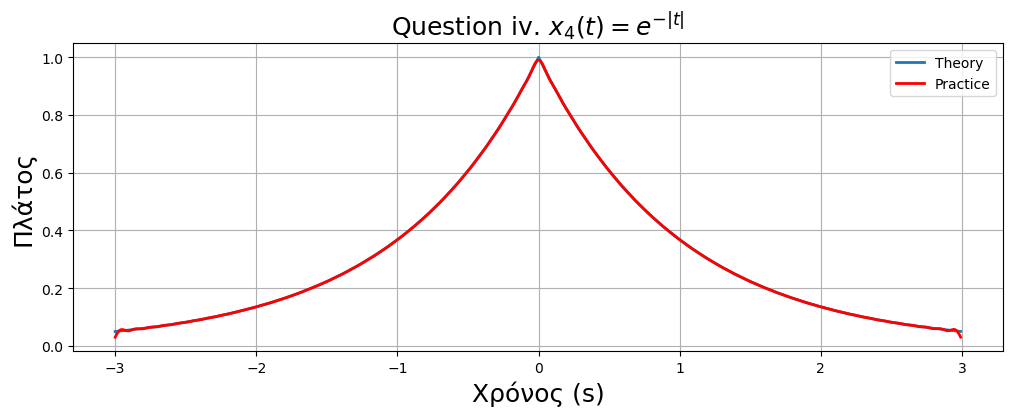

In [20]:
# iv)
t = np.arange(start=-3, stop=3, step=dt)
x4 = np.exp(-np.abs(t)) # INSERT CODE HERE - υλοποιήστε το σήμα κανονικά στο πεδίο του χρόνου
x4_est = ctft2ictft(f, df, t, dt, x4) # INSERT CODE HERE - χρησιμοποιήστε την ctft2ictft
plotter(time=t, signal=x4, signal_est=x4_est.real, title="Question iv. $x_4(t)=e^{-|t|}$")

Αν τα κανετε όλα σωστά, θα πάρετε τα παρακάτω σχήματα:

![foursignals.png](./files/foursignals.png)

---
---